In [ ]:
from pathlib import Path

import tifffile
import pickle
import pynapple as nap

import numpy as np
# from notebooks.data_synchronization_barcode import tsync_barcode
%matplotlib widget

import matplotlib.pyplot as plt

from ipywidgets import interact
import ipywidgets as widgets

from tqdm.notebook import tqdm

import pandas as pd

# import seaborn as sns
# custom_params = {"axes.spines.right": False, "axes.spines.top": False, "figure.figsize": (8, 4)}
# sns.set_context("paper")
# sns.set_theme(style="ticks", palette="colorblind", font_scale=1.3, rc=custom_params)


In [16]:
data_path = Path("/data/Rotinda/20260506_day6")

In [2]:
root_path = Path("/vol/battaglialab/imaging1/rotinda/AATC/490212_Donatello/20260614/AATC_r1results/behavior_sync")

project = nap.load_folder(root_path)
print(project)

📂 behavior_sync
├── 📂 behavior
├── 📂 plane0
├── 20260614-144107_085_barcode_data.npz    |        npz
└── 20260614-144107_085_frames_time_idx.npz         |        Tsd

In [3]:
session = project
session.view

📂 behavior_sync
├── 📂 behavior
│   ├── Shock_Grid.npz  |        Tsd
│   ├── Trigger_Barcode.npz     |        Tsd
│   ├── Nature_Environment.npz  |        Tsd
│   ├── Trigger_AATC.npz        |        Tsd
│   ├── licks.npz       |        Tsd
│   ├── Reward_Zone.npz         |        Tsd
│   ├── Lick_Detection.npz      |        Tsd
│   ├── Wheel_Encoder_A.npz     |        Tsd
│   ├── Tone_2.npz      |        Tsd
│   ├── Speaker.npz     |        Tsd
│   ├── GND.npz         |        Tsd
│   ├── Binary_Lick.npz         |        Tsd
│   ├── OFL.npz         |        Tsd
│   ├── Valve.npz       |        Tsd
│   ├── Scanner_Frame_Clock_Input.npz   |        Tsd
│   ├── Halloween_Environment.npz       |        Tsd
│   ├── Wheel_Encoder_B.npz     |        Tsd
│   ├── Tone_1.npz      |        Tsd
│   ├── startTS.npz     |        Tsd
│   ├── longVar.npz     |        TsdFrame
│   ├── Pre_Shock.npz   |        Tsd
│   ├── Test_Shock.npz  |        Tsd
│   ├── Breathing_Sensor.npz    |        Tsd
│   ├── Trigger_C.npz   |        Tsd
│   ├── corrected_distance.npz  |        Tsd
│   ├── packetNums.npz  |        Tsd
│   ├── Wheel_Encoder_X.npz     |        Tsd
│   ├── transmitTS.npz  |        Tsd
│   ├── Pin_Sync_LED.npz        |        Tsd
│   ├── Barcode_Scanner.npz     |        Tsd
│   └── uncorrected_distance.npz        |        Tsd
├── 📂 plane0
│   ├── Fneu_sync.npz   |        TsdFrame
│   ├── F_sync.npz      |        TsdFrame
│   └── spks_sync.npz   |        TsdFrame
├── 20260614-144107_085_barcode_data.npz    |        npz
└── 20260614-144107_085_frames_time_idx.npz         |        Tsd

In [6]:
F_sync = session['plane0']['F_sync']

In [9]:
path_all = root_path.parent

In [11]:
path_raw = path_all / "AATC_r1_51/plane0"

In [13]:
F = np.load(path_raw / "F.npy")

In [14]:
F


array([[4225.688 , 4634.24  , 4141.078 , ..., 4673.9883, 4440.2524,
        4734.87  ],
       [3068.6465, 3638.6318, 3099.122 , ..., 4145.578 , 4074.0103,
        3621.0393],
       [3794.1165, 4117.0693, 3918.0225, ..., 3553.1128, 3109.692 ,
        3245.1826],
       ...,
       [1865.2795, 2035.2793, 1878.5752, ..., 1628.5687, 2205.1929,
        2211.017 ],
       [4819.727 , 2525.281 , 2719.647 , ..., 2160.941 , 2918.8857,
        2173.311 ],
       [3607.4941, 4790.2266, 4324.1523, ..., 5197.979 , 4579.4775,
        3550.5051]], shape=(2092, 40946), dtype=float32)

In [15]:
spks = np.load(path_raw / "spks.npy")

In [16]:
spks

array([[  0.     , 134.67274,   0.     , ...,   0.     ,   0.     ,
          0.     ],
       [  0.     , 245.92336,   0.     , ...,   0.     ,   0.     ,
          0.     ],
       [  0.     , 267.04263,   0.     , ...,   0.     ,   0.     ,
          0.     ],
       ...,
       [  0.     ,   0.     ,   0.     , ...,   0.     , 195.65675,
          0.     ],
       [  0.     ,   0.     ,   0.     , ...,   0.     ,   0.     ,
          0.     ],
       [  0.     ,  64.20259,   0.     , ..., 521.02625,   0.     ,
          0.     ]], shape=(2092, 40946), dtype=float32)

In [7]:
for f in root_path.glob("*behavior_sync_stats.pkl"):
    sync_stats_file = f

print(sync_stats_file)


# sync_stats_file = root_path / "preprocessing_results/behavior_sync" / "20251118-152602_925_behavior_sync_stats.pkl"
with open(sync_stats_file, "rb") as f:
    sync_stats = pickle.load(f)

/data/Rotinda/20260506_day6/day6_01_results/behavior_sync/20260506-140414_484_behavior_sync_stats.pkl


In [17]:
frame_clock = session['behavior']['Scanner_Frame_Clock_Input']

In [19]:
onsets = np.nonzero(np.diff(frame_clock.d) == 1)[0] + 1

In [20]:
onsets

array([  10877,   10910,   10943, ..., 1321233, 1321266, 1321299],
      shape=(39245,))

In [8]:
sync_stats

{'session': '20260506-140414_484',
 'max_ts_gap': 880000,
 'gap_locations': array([1.35019799e+09, 1.43612699e+09, 1.97458199e+09]),
 'has_barcode': True,
 'barcode_shift': 1135.7312957450001,
 'barcode_frame_matches':       A_index  B_index      A_value      B_value  abs_difference  difference
 0           0        6  1135.931596  1135.923993        0.007603   -0.007603
 1           1       12  1136.131897  1136.123993        0.007904   -0.007904
 2           2       21  1136.432349  1136.424993        0.007356   -0.007356
 3           3       34  1136.866337  1136.858993        0.007344   -0.007344
 4           4       40  1137.066639  1137.058993        0.007646   -0.007646
 ...       ...      ...          ...          ...             ...         ...
 4248     4253    39208  2446.523359  2446.523993        0.000634    0.000634
 4249     4254    39217  2446.823880  2446.824993        0.001113    0.001113
 4250     4255    39223  2447.024227  2447.024993        0.000766    0.000766
 4

In [9]:
def extract_rewards(r: nap.IntervalSet):
    rew_tsd = r.threshold(0.5)
    rew_is = rew_tsd.time_support.merge_close_intervals(threshold=0.2)
    return nap.Ts(rew_is.start)

In [10]:
rewards = extract_rewards(session["behavior"]["Valve_Toggle"])

In [11]:
spks = session['plane0']['spks_sync']

In [12]:
spks

Time (s)           0        1    2         3         4  ...
-----------  -------  -------  ---  --------  --------  -----
1135.923993   0         0        0    0         0       ...
1136.123993   0         0        0  268.919     0       ...
1136.424993   0         0        0    0         0       ...
1136.858993   0         0        0    0       104.92    ...
1137.058993   0         0        0    0         0       ...
1137.358993   0         0        0    0         0       ...
1137.559993  62.8011  230.196    0  107.994     0       ...
...                                                     ...
2446.022993   0         0        0    0        86.038   ...
2446.223993   0         0        0    0         0       ...
2446.523993   0         0        0    0        39.3816  ...
2446.824993   0         0        0   40.9638    0       ...
2447.024993   0         0        0    0         0       ...
2447.358993  58.5109    0        0  138.564     0       ...
2447.558993   0         0        0    

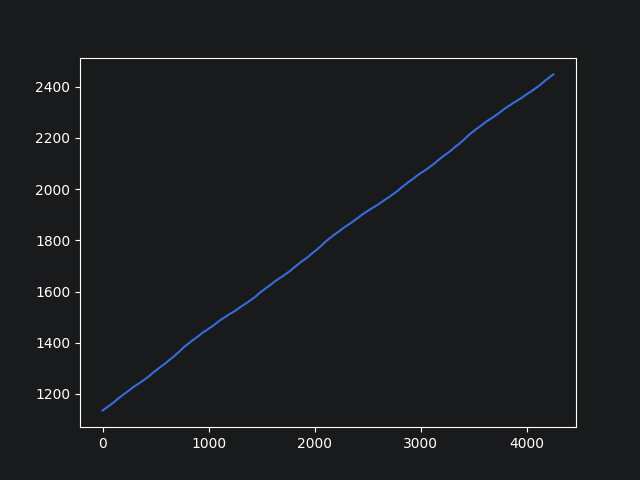

In [14]:
plt.plot(spks.t)

In [ ]:
def spks_as_tsgroup(threshold: float, spks: nap.TsdFrame):
    t = spks.t
    n_cells = spks.shape[1]
    ts_dict = {i: nap.Ts(t[spks[:, i] > threshold]) for i in range(n_cells)}
    return nap.TsGroup(ts_dict)

In [ ]:
spikes = spks_as_tsgroup(100, spks)

In [ ]:
peth = nap.compute_perievent(data=spikes, events=rewards, window=(-2, 5))
peth

In [ ]:
def plot_peth(unit_peth, unit_peth_counts, ax_mean, ax_spikes, color=None):
    mean = np.mean(unit_peth_counts / bin_size, axis=1)
    ax_mean.plot(mean, color=color)
    ax_mean.set_ylabel("spikes/s")
    ax_mean.axvline(0.0, color="gray", linestyle="--")
    ax_spikes.plot(unit_peth.to_tsd(), "|", markersize=5, color=color)
    ax_mean.set_xlabel("time from event (s)")
    ax_spikes.set_ylabel("event")
    ax_spikes.axvline(0.0, color="gray", linestyle="--")


fig, (ax_spikes, ax_mean) = plt.subplots(
    2, 1, sharex=True, height_ratios=[1, 0.3], figsize=(6, 6), gridspec_kw={"hspace": 0.3}
)
plot_peth(peth, peth_counts, ax_mean, ax_spikes)
ax_spikes.set_title("peri = nap.compute_perievent(spikes, events)")
ax_mean.set_title("peri.count(bin_size) / bin_size")

In [ ]:
fig, axs = plt.subplots(
    2,
    len(tsgroup),
    sharey="row",
    sharex=True,
    height_ratios=[0.3, 1.0],
    figsize=(15, 8),
)
fig.suptitle("nap.compute_perievent(tsgroup, stimuli, (-0.1, 0.4)", y=1.02)
for i, (unit, unit_axs) in enumerate(zip(tsgroup, axs.T)):
    plot_peth(peth[unit], peth[unit].count(bin_size), *unit_axs, color=plt.cm.tab10(i))
    unit_axs[0].set_title(f"unit {unit}")

In [ ]:
(fig, ax) = plt.subplots(figsize=(10, 4))

ax.plot(spks[:,421])
ax.plot(spikes[421].fillna(0), '.', label="cell 421")

In [ ]:
rewards

In [ ]:

r = session["behavior"]["Valve_Toggle"]

In [ ]:
r